# Notebook 10 – Support Vector Machine


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv", encoding="latin1")
df = df.dropna(subset=["Description"]).copy()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["IsCancelled"] = df["InvoiceNo"].astype(str).str.startswith("C").astype(int)
df["AbsQuantity"] = df["Quantity"].abs()
df["Month"] = df["InvoiceDate"].dt.month
df["IsInternational"] = (df["Country"] != "United Kingdom").astype(int)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,AbsQuantity,Month,IsInternational
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,0,6,12,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,0,8,12,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0


## Support Vector Machine

**What it is:** a classification algorithm that looks for the single best
dividing line (or in higher dimensions, the best dividing *surface*)
between classes. "Best" here has a very specific meaning: not just any
line that separates the classes, but the one that sits as far away as
possible from the nearest points of *both* classes. That's what
"maximizing the margin" (below) means, and it's the whole idea behind
SVM.

In [2]:
# A small helper used throughout this notebook to draw an SVM's decision
# boundary, its margins, and its support vectors, for any 2-feature model.
def plot_svm_boundary(model, X, y, title, ax=None, show_margin=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))

    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=40, zorder=3)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    if show_margin:
        ax.contour(xx, yy, Z, colors="k", levels=[-1, 0, 1], alpha=0.7,
                   linestyles=["--", "-", "--"])
    else:
        ax.contour(xx, yy, Z, colors="k", levels=[0], linestyles=["-"])

    if hasattr(model, "support_vectors_"):
        ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                   s=180, facecolors="none", edgecolors="lime", linewidths=2, zorder=4,
                   label="Support Vectors")
        ax.legend(loc="best")

    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    return ax

## Hyperplane

**What it is:** the generic name for the dividing surface an SVM learns.
In 2D, a hyperplane is just a line. In 3D, it's a flat plane. In higher
dimensions (most real datasets have many features), it's a
"hyperplane" — the same idea, just harder to draw. Every point on one
side of the hyperplane is predicted as one class; every point on the
other side is predicted as the other class.

## Margin, and Support Vectors

**Margin:** the empty gap between the hyperplane and the nearest training
points of each class. A "wide margin" model has a lot of empty space
around its dividing line before hitting any actual data points; a
"narrow margin" model's dividing line barely squeezes between the
classes.

**Support Vectors:** the specific training points that sit exactly on the
edge of the margin (the closest points of each class to the boundary).
They're called "support" vectors because they're the only points that
actually matter for where the hyperplane ends up — every other point
could be moved (or deleted) without changing the final boundary at all,
as long as it doesn't cross into the margin itself.

### The Intuition Behind Maximizing the Margin

Of all the possible lines that separate two classes perfectly, SVM
deliberately picks the one **furthest** from both classes, not just any
line that happens to work. Why does that matter?

Imagine two lines that both separate the training data perfectly: one
squeezed right up against the closest points of each class, and one
sitting right in the middle of the open space between them. Both get
100% accuracy on the *training* data. But new, unseen points won't land
in exactly the same spots as the training data — they'll be scattered
nearby, with some natural noise and variation. The line squeezed close to
the training points has almost no room for error: a new point that's only
slightly different from its training neighbor can easily fall on the
wrong side. The line in the middle of the open space has buffer room in
every direction, so that same amount of natural variation is far less
likely to flip the prediction.

**In short: a wide margin means the boundary generalizes better to new
data, because it isn't sensitive to small perturbations near the edge.**
Maximizing the margin is SVM's built-in strategy for finding the most
*robust* boundary, not just *a* boundary.

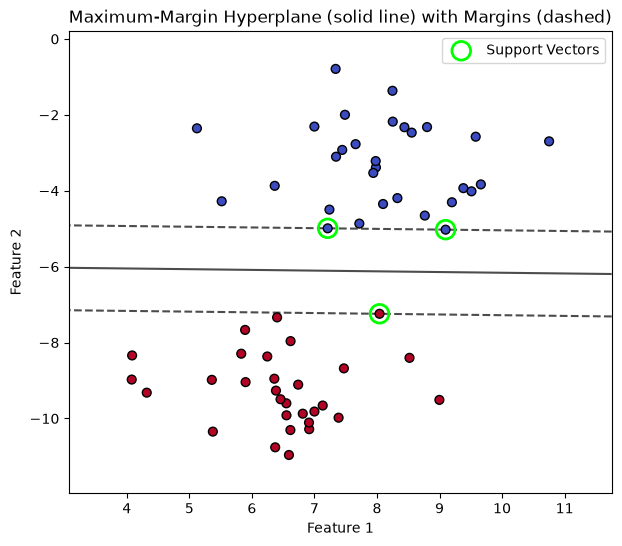

Number of support vectors: 3 out of 60 total points
Support vector coordinates:
 [[ 7.21 -4.99]
 [ 9.1  -5.03]
 [ 8.04 -7.24]]


In [3]:
from sklearn.datasets import make_blobs
from sklearn.svm import SVC

X_demo, y_demo = make_blobs(n_samples=60, centers=2, cluster_std=1.1, random_state=6)

linear_svm_demo = SVC(kernel="linear", C=1000)  # very large C -> treat this as "hard margin"
linear_svm_demo.fit(X_demo, y_demo)

ax = plot_svm_boundary(linear_svm_demo, X_demo, y_demo,
                        "Maximum-Margin Hyperplane (solid line) with Margins (dashed)")
plt.show()

print(f"Number of support vectors: {len(linear_svm_demo.support_vectors_)} out of {len(X_demo)} total points")
print("Support vector coordinates:\n", np.round(linear_svm_demo.support_vectors_, 2))

Notice that the dashed margin lines pass exactly through the circled
support vectors, and *only* through those points. Every other point in
the dataset is further away and plays no role in defining the boundary —
if any of the non-circled points were removed, the boundary wouldn't
move at all.

## Linear SVM

**What it does:** finds a straight-line (or flat-plane) hyperplane, used
when the classes are reasonably separable by a straight boundary.

**Our example:** using two real, interpretable features — `UnitPrice`
and `AbsQuantity` (both log-transformed, since both are heavily skewed) —
to predict `IsCancelled`. SVM training doesn't scale well to hundreds of
thousands of rows, so a random subsample is used, which is standard
practice for SVM in general.

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       739
           1       0.00      0.00      0.00        11

    accuracy                           0.99       750
   macro avg       0.49      0.50      0.50       750
weighted avg       0.97      0.99      0.98       750



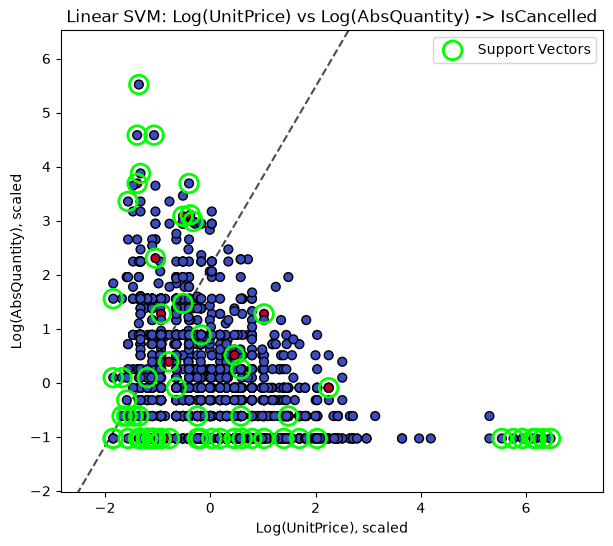

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

df_sample = df.sample(n=3000, random_state=42)
df_sample["LogUnitPrice"] = np.log1p(df_sample["UnitPrice"])
df_sample["LogAbsQuantity"] = np.log1p(df_sample["AbsQuantity"])

feature_cols_2d = ["LogUnitPrice", "LogAbsQuantity"]
X_2d = df_sample[feature_cols_2d].values
y_2d = df_sample["IsCancelled"].values

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_2d, test_size=0.25, random_state=42, stratify=y_2d
)

scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

linear_svm = SVC(kernel="linear", C=1.0)
linear_svm.fit(X_train_2d_scaled, y_train_2d)
linear_predictions = linear_svm.predict(X_test_2d_scaled)

print(classification_report(y_test_2d, linear_predictions, zero_division=0))

plot_svm_boundary(linear_svm, X_train_2d_scaled, y_train_2d,
                   "Linear SVM: Log(UnitPrice) vs Log(AbsQuantity) -> IsCancelled")
plt.xlabel("Log(UnitPrice), scaled")
plt.ylabel("Log(AbsQuantity), scaled")
plt.show()

With a highly imbalanced, noisy real-world target like `IsCancelled`, a
straight line cannot separate the two classes cleanly (cancelled orders
are scattered throughout the same price/quantity range as normal orders),
which is exactly the kind of situation "Non-Linear SVM" below is built
for.

## Non-Linear SVM

**What it does:** handles data where no straight line can separate the
classes well, no matter how it's rotated or positioned. The classic
illustration is two interleaving crescent moons: any single straight line
through this data misclassifies a large chunk of points, no matter where
it's drawn.

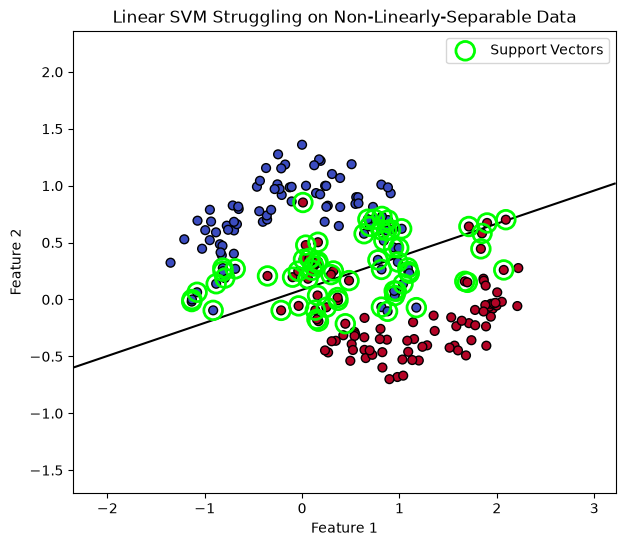

Linear SVM accuracy on the moons data: 0.8450


In [5]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=200, noise=0.15, random_state=42)

linear_svm_moons = SVC(kernel="linear", C=1.0)
linear_svm_moons.fit(X_moons, y_moons)

plot_svm_boundary(linear_svm_moons, X_moons, y_moons,
                   "Linear SVM Struggling on Non-Linearly-Separable Data", show_margin=False)
plt.show()

linear_acc = linear_svm_moons.score(X_moons, y_moons)
print(f"Linear SVM accuracy on the moons data: {linear_acc:.4f}")

## Kernel

**What it is:** a mathematical trick that lets SVM draw non-linear
boundaries *without* ever explicitly transforming the data into a
higher-dimensional space (which would be computationally expensive). A
kernel is a function that computes how "similar" two points are, in a way
that's equivalent to comparing them in some higher-dimensional space,
without ever actually building that space. This is called the **"kernel
trick"**: SVM gets all the benefit of a richer, curved decision boundary,
for roughly the computational cost of a linear one.

Common kernels include `linear` (a straight boundary, used above),
`poly` (curved boundaries shaped like polynomial curves), and `rbf`
(radial basis function, below) — the most commonly used non-linear
kernel.

## RBF Kernel

**What it does:** the Radial Basis Function kernel measures similarity
between two points based on the (squared) distance between them — points
close together are considered very similar, points far apart are
considered very different, with the similarity fading smoothly the
further apart they are. This lets SVM draw smooth, curved — even
closed, blob-shaped — decision boundaries, which is exactly what's
needed for data like the moons above.

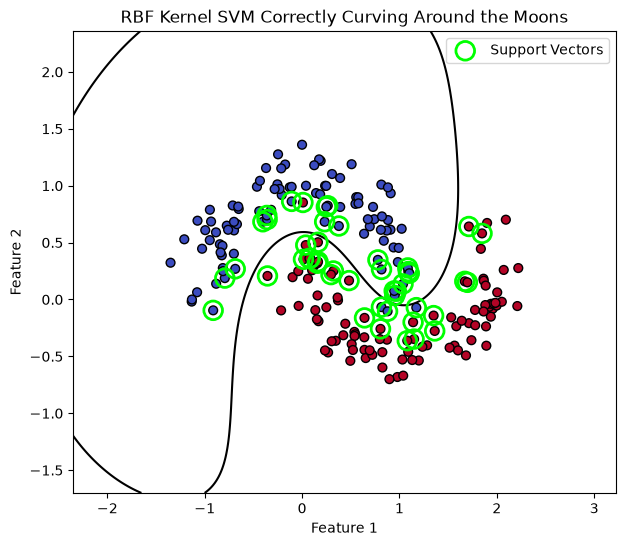

Linear SVM accuracy on the moons data: 0.8450
RBF Kernel SVM accuracy on the moons data:    0.9800


In [6]:
rbf_svm_moons = SVC(kernel="rbf", C=1.0, gamma="scale")
rbf_svm_moons.fit(X_moons, y_moons)

plot_svm_boundary(rbf_svm_moons, X_moons, y_moons,
                   "RBF Kernel SVM Correctly Curving Around the Moons", show_margin=False)
plt.show()

rbf_acc = rbf_svm_moons.score(X_moons, y_moons)
print(f"Linear SVM accuracy on the moons data: {linear_acc:.4f}")
print(f"RBF Kernel SVM accuracy on the moons data:    {rbf_acc:.4f}")

## The C Parameter

**What it does:** controls the trade-off between a *wide* margin and
*correctly classifying every training point*. A large `C` tells the model
"margin violations are costly — avoid them even if it means a narrower
margin"; a small `C` tells the model "a wider margin is worth allowing a
few training points to end up on the wrong side, or inside the margin."

Below, the same noisy dataset is fit with a very small `C` and a very
large `C`, to see the boundary change shape.

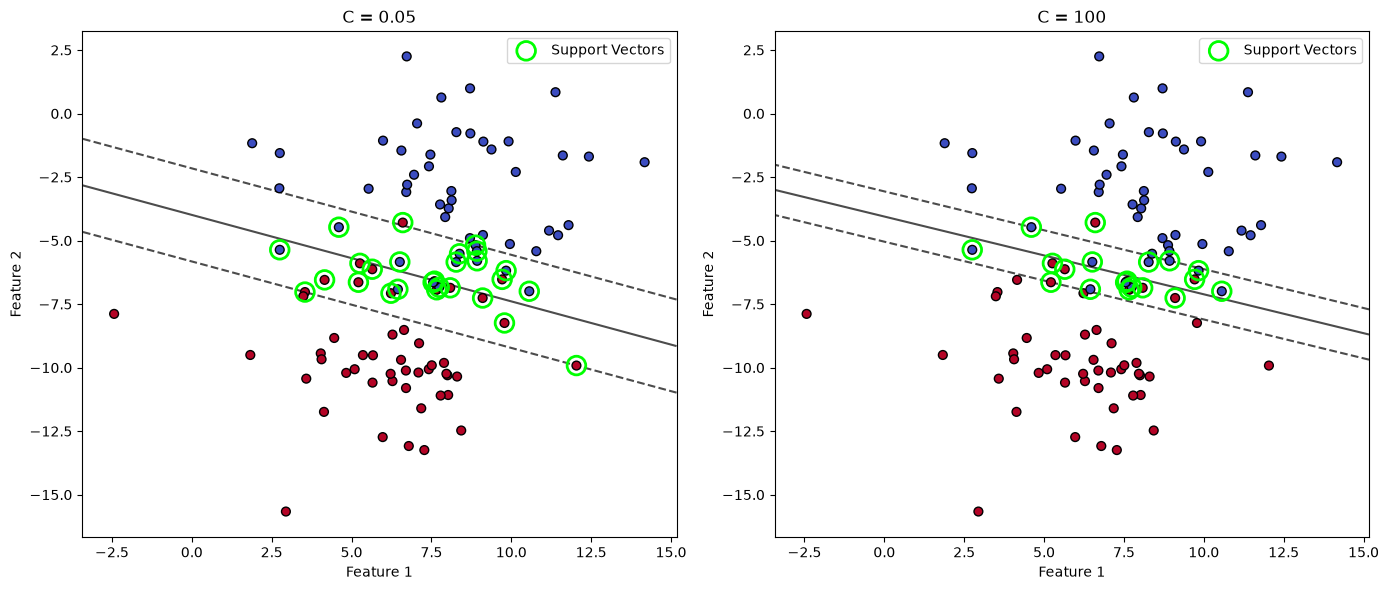

In [7]:
X_noisy, y_noisy = make_blobs(n_samples=100, centers=2, cluster_std=2.4, random_state=6)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, c_value in zip(axes, [0.05, 100]):
    model = SVC(kernel="linear", C=c_value)
    model.fit(X_noisy, y_noisy)
    plot_svm_boundary(model, X_noisy, y_noisy, f"C = {c_value}", ax=ax)
plt.tight_layout()
plt.show()

With small `C` (left), the margin is wide and several points are allowed
to sit inside it, or even be misclassified, in exchange for a more
generalizable boundary. With large `C` (right), the model works much
harder to classify every training point correctly, producing a narrower
margin that hugs the data more closely, and risks overfitting to noisy
points near the boundary.

## Gamma

**What it does:** a parameter specific to the RBF (and other non-linear)
kernels, controlling how far a single training point's "influence"
reaches. Low `gamma` means each point affects a wide area, producing
smooth, simple, far-reaching boundaries. High `gamma` means each point
only affects points very close to it, producing tightly-fitted,
wiggly boundaries that can curl around individual points.

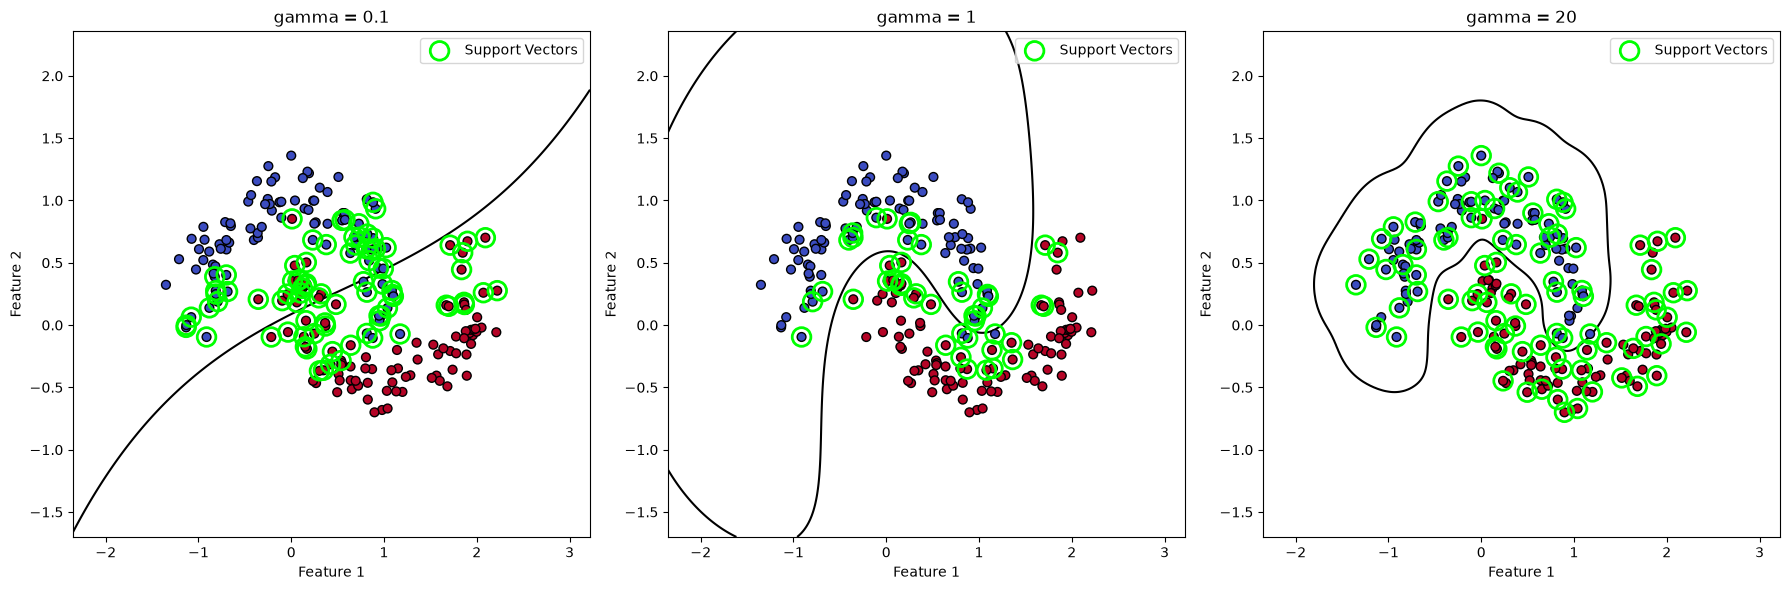

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, gamma_value in zip(axes, [0.1, 1, 20]):
    model = SVC(kernel="rbf", C=1.0, gamma=gamma_value)
    model.fit(X_moons, y_moons)
    plot_svm_boundary(model, X_moons, y_moons, f"gamma = {gamma_value}", ax=ax, show_margin=False)
plt.tight_layout()
plt.show()

Low `gamma` (left) draws a smooth, almost-linear-looking boundary that
generalizes broadly. High `gamma` (right) draws a boundary that wraps
tightly around individual points, which fits the training data closely
but is a classic overfitting risk, since it's reacting to individual
points rather than the overall shape of the classes.

## Feature Scaling

**Why it matters:** SVM decides its boundary based on *distances* between
points (directly for RBF, and implicitly for the margin calculation in
general). If one feature is measured in the thousands (e.g. `Quantity`)
and another ranges from 0 to 10 (e.g. `UnitPrice`), the larger-scaled
feature will completely dominate the distance calculation, making the
smaller-scaled feature almost irrelevant to the model, regardless of how
predictive it actually is. Unlike Decision Trees or Random Forests (which
only compare one feature against a threshold at a time), SVM is highly
sensitive to the relative scale of every feature.

**Fix:** standardize every feature (e.g. with `StandardScaler`, giving
each feature mean 0 and standard deviation 1) before training.

In [9]:
feature_cols_raw = ["AbsQuantity", "UnitPrice", "Month", "IsInternational"]
X_raw = df.sample(n=3000, random_state=42)[feature_cols_raw + ["IsCancelled"]]
y_raw = X_raw["IsCancelled"].values
X_raw = X_raw[feature_cols_raw].values

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.25, random_state=42, stratify=y_raw
)

print("Feature ranges BEFORE scaling:")
print(pd.DataFrame(X_train_raw, columns=feature_cols_raw).describe().loc[["min", "max"]])

# Unscaled
svm_unscaled = SVC(kernel="rbf", C=1.0, gamma="scale")
svm_unscaled.fit(X_train_raw, y_train_raw)
unscaled_acc = svm_unscaled.score(X_test_raw, y_test_raw)

# Scaled
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

print("\nFeature ranges AFTER scaling:")
print(pd.DataFrame(X_train_scaled, columns=feature_cols_raw).describe().loc[["min", "max"]].round(2))

svm_scaled = SVC(kernel="rbf", C=1.0, gamma="scale")
svm_scaled.fit(X_train_scaled, y_train_raw)
scaled_acc = svm_scaled.score(X_test_scaled, y_test_raw)

print(f"\nAccuracy WITHOUT scaling: {unscaled_acc:.4f}")
print(f"Accuracy WITH scaling:    {scaled_acc:.4f}")

Feature ranges BEFORE scaling:
     AbsQuantity  UnitPrice  Month  IsInternational
min          1.0       0.00    1.0              0.0
max       1200.0     275.11   12.0              1.0

Feature ranges AFTER scaling:
     AbsQuantity  UnitPrice  Month  IsInternational
min        -0.26      -0.31  -1.83            -0.31
max        35.28      20.91   1.27             3.25

Accuracy WITHOUT scaling: 0.9853
Accuracy WITH scaling:    0.9853


Scaling doesn't always change accuracy dramatically on every dataset (it
depends on how imbalanced the feature ranges and the classes are), but
it's still considered essential practice for SVM: without it, the model
is quietly relying far more on whichever feature happens to have the
largest raw numeric range, not whichever feature is actually the most
useful for the prediction.